# Abigale notebook

In [1]:
import ocean_skill as osk
from ocean_skill.build import build_kerchunk, build_catalog

## Set up model catalog

This saves the kerchunk representation of the model output in the docs directory as a parquet file - we'll find a better place later.

In [2]:
# model output is in
model_base = "/anvil/scratch/x-smaticka/sims_runtime/cstar/pac_dt_ramp/pac_dt_ramp/tasks/third_1wks/joined_output/"
# grid is at 
grid_loc = "/anvil/scratch/x-smaticka/sims_runtime/cstar/pac_dt_ramp/pac_dt_ramp/tasks/third_1wks/input/input_datasets/PACMED12km_spec_config_WithRivers_grid.nc"
# name of catalog - also using for the dataset name since there is only one in here
cat_name = "pac_dt_ramp"


In [3]:

refs = build_kerchunk({cat_name: "output_rst.*.nc"},
                      root=model_base, 
                      grid=grid_loc, 
                      keep="latest-per-file",  # use this for restart files to keep the main time step
                      out_dir='.')
build_catalog(refs, f"catalogs/{cat_name}.yaml", title=cat_name)

/home/x-kthyng/.conda/envs/ocean-skill/lib/python3.12/site-packages/zarr/core/dtype/npy/bytes.py:386: UnstableSpecificationWarning: The data type (NullTerminatedBytes(length=1)) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)


PosixPath('catalogs/pac_dt_ramp.yaml')

In [4]:
# check out the model output
ds = osk.read(cat_name)

/home/x-kthyng/.conda/envs/ocean-skill/lib/python3.12/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(


## WOA Nutrients - Jan Monthly Mean

Monthly being compared to daily at surface

### Surface

1st time running plot: 2.5 min. 2nd time: 6s.

<timed exec>:4: UserWarning: 'nitrate' resolved to standard_name 'mole_concentration_of_nitrate_in_sea_water' (compare variables=)
<timed exec>:4: UserWarning: 'phosphate' resolved to standard_name 'mole_concentration_of_phosphate_in_sea_water' (compare variables=)
<timed exec>:4: UserWarning: 'silicate' resolved to standard_name 'mole_concentration_of_silicate_in_sea_water' (compare variables=)
<timed exec>:4: UserWarning: 'oxygen' resolved to standard_name 'mole_concentration_of_dissolved_molecular_oxygen_in_sea_water' (compare variables=)


CPU times: user 5.43 s, sys: 679 ms, total: 6.11 s
Wall time: 6.13 s


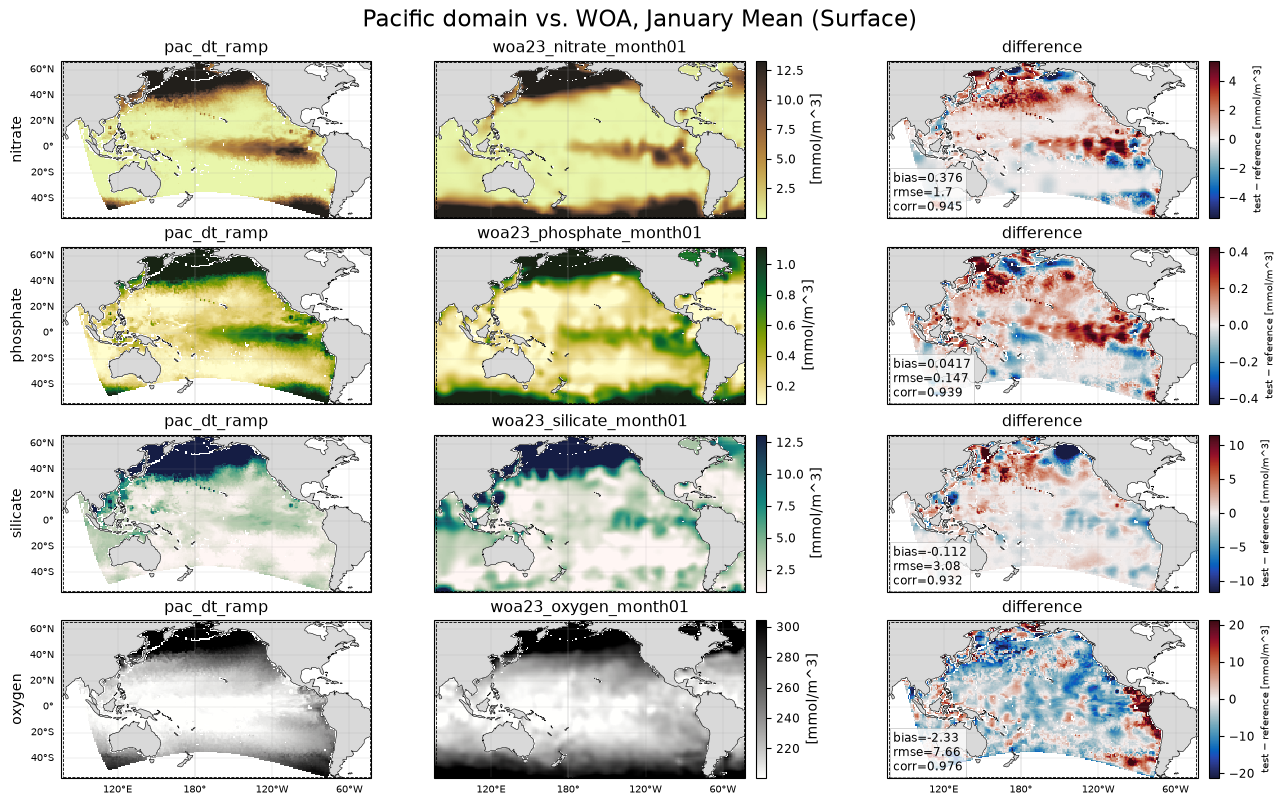

In [23]:
%%time

# these are being referred to by nicknames
vars_to_plot = ["nitrate", "phosphate", "silicate", "oxygen"]

woa_surface = osk.compare(
    aggregate={"test": {"time": {"groupby": "month", "reduce": "mean"}},
           "reference": {"time": "mean"}},
    reference=["woa23_nitrate_month01", "woa23_phosphate_month01", "woa23_silicate_month01", "woa23_oxygen_month01"],
    test=cat_name,  # using cat_name here because it is used for the model/dataset name too
    variables=vars_to_plot,
    select={"test": {"depth": "surface", "month": 1},
            "reference": {"depth": "surface"}},
)

fig = woa_surface.plot(zoom=1.5, title="Pacific domain vs. WOA, January Mean (Surface)")

### 100m Depth

<timed exec>:4: UserWarning: 'nitrate' resolved to standard_name 'mole_concentration_of_nitrate_in_sea_water' (compare variables=)
<timed exec>:4: UserWarning: 'phosphate' resolved to standard_name 'mole_concentration_of_phosphate_in_sea_water' (compare variables=)
<timed exec>:4: UserWarning: 'silicate' resolved to standard_name 'mole_concentration_of_silicate_in_sea_water' (compare variables=)
<timed exec>:4: UserWarning: 'oxygen' resolved to standard_name 'mole_concentration_of_dissolved_molecular_oxygen_in_sea_water' (compare variables=)


CPU times: user 5.73 s, sys: 654 ms, total: 6.38 s
Wall time: 6.4 s


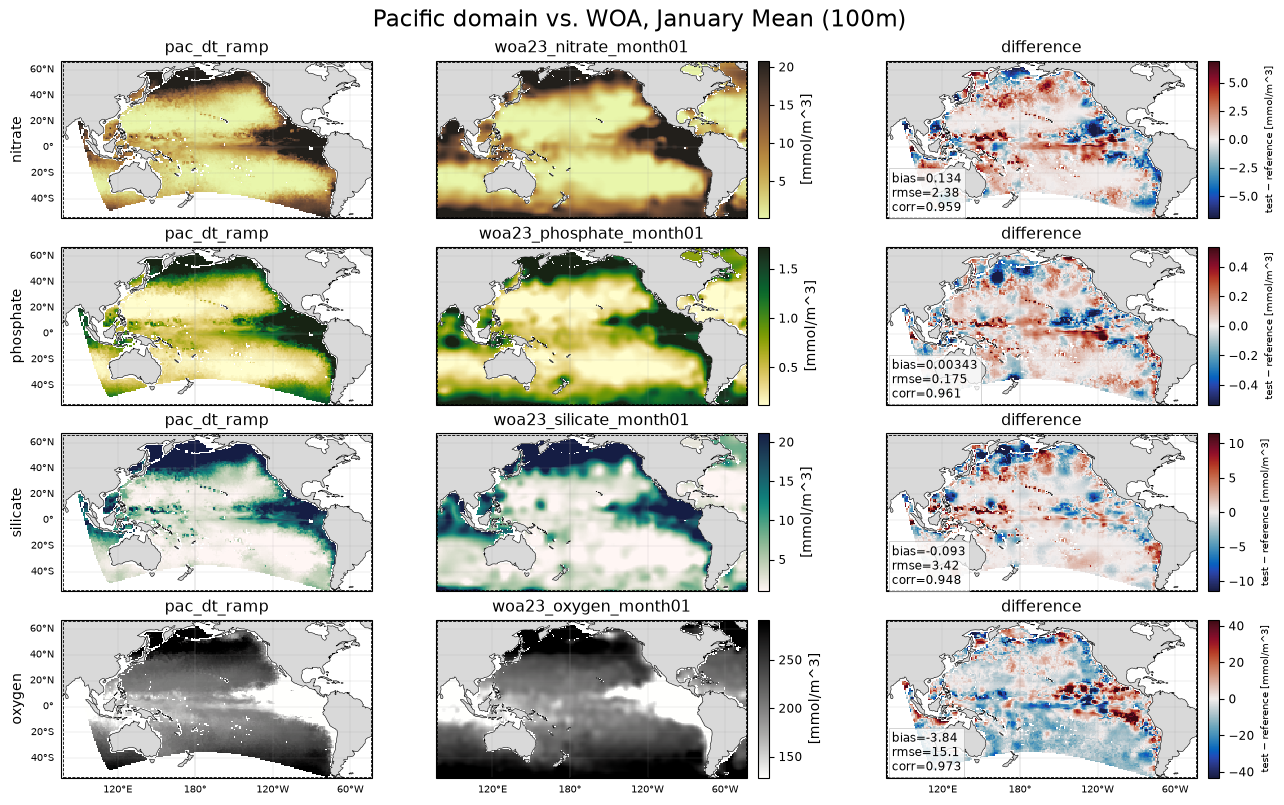

In [24]:
%%time

# these are being referred to by nicknames
vars_to_plot = ["nitrate", "phosphate", "silicate", "oxygen"]

woa_100m = osk.compare(
    aggregate={"test": {"time": {"groupby": "month", "reduce": "mean"}},
           "reference": {"time": "mean"}},
    reference=["woa23_nitrate_month01", "woa23_phosphate_month01", "woa23_silicate_month01", "woa23_oxygen_month01"],
    test=cat_name,  # using cat_name here because it is used for the model/dataset name too
    variables=vars_to_plot,
    select={"test": {"depth": 100, "month": 1},
            "reference": {"depth": 100}},
)

fig = woa_100m.plot(zoom=1.5, title="Pacific domain vs. WOA, January Mean (100m)")

## GLODAP Alk and DIC - Climatology

Average our model output to do this comparison - can't compute a real climatology for the model output currently.

### Surface

48 vs 5 sec

In [7]:
osk.describe("glodap")

source: GLODAPv2.2016b Mapped Climatologies:glodap
  path: /home/x-kthyng/packages/ocean-skill/catalogs/glodap.catalog.yaml
  climatology: True
  depth_coord: depth_surface
  featureType: grid
  institution: NOAA NCEI / GLODAPv2
  nominal_resolution_km: 111
  notes: Open-ocean product: marginal seas are largely masked (~8% coverage in the Gulf of Mexico).
  references: Olsen et al. 2016 (ESSD); Lauvset et al. GLODAPv2.2016b
  standard_names: {'NO3': 'mole_concentration_of_nitrate_in_sea_water', 'PO4': 'mole_concentration_of_phosphate_in_sea_water', 'TAlk': 'sea_water_alkalinity_expressed_as_mole_equivalent', 'TCO2': 'mole_concentration_of_dissolved_inorganic_carbon_in_sea_water', 'oxygen': 'mole_concentration_of_dissolved_molecular_oxygen_in_sea_water', 'salinity': 'sea_water_practical_salinity', 'silicate': 'mole_concentration_of_silicate_in_sea_water', 'temperature': 'sea_water_potential_temperature'}
  title: GLODAPv2.2016b Mapped Climatology
  variables: ['mole_concentration_of_dissolved_inorganic_carbon_in_sea_water', 'mole_concentration_of_dissolved_molecular_oxygen_in_sea_water', 'mole_concentration_of_nitrate_in_sea_water', 'mole_concentration_of_phosphate_in_sea_water', 'mole_concentration_of_silicate_in_sea_water', 'sea_water_alkalinity_expressed_as_mole_equivalent', 'sea_water_potential_temperature', 'sea_water_practical_salinity']

<timed exec>:3: UserWarning: 'alkalinity' resolved to standard_name 'sea_water_alkalinity_expressed_as_mole_equivalent' (compare variables=)
<timed exec>:3: UserWarning: 'dissolved_inorganic_carbon' resolved to standard_name 'mole_concentration_of_dissolved_inorganic_carbon_in_sea_water' (compare variables=)


CPU times: user 2.84 s, sys: 381 ms, total: 3.22 s
Wall time: 3.23 s


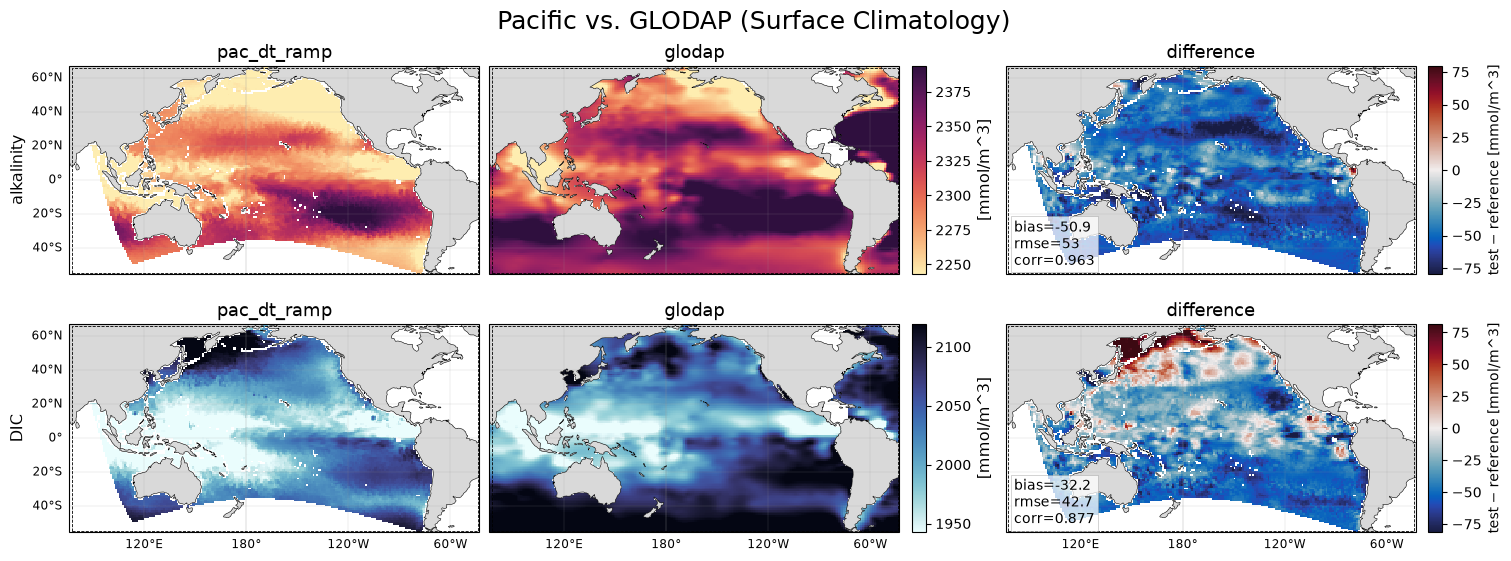

In [25]:
%%time

vars_to_plot = ["alkalinity", "dissolved_inorganic_carbon"]

glodap_surface = osk.compare(
    aggregate={"time": "mean"},
    reference=["glodap"],
    test=cat_name,
    variables=vars_to_plot,
    depths=["surface"],  # depths is a convenience
)
fig = glodap_surface.plot(figsize=(15,5.5), title="Pacific vs. GLODAP (Surface Climatology)")

### 100m Depth

<timed exec>:3: UserWarning: 'alkalinity' resolved to standard_name 'sea_water_alkalinity_expressed_as_mole_equivalent' (compare variables=)
<timed exec>:3: UserWarning: 'dissolved_inorganic_carbon' resolved to standard_name 'mole_concentration_of_dissolved_inorganic_carbon_in_sea_water' (compare variables=)


CPU times: user 2.87 s, sys: 368 ms, total: 3.24 s
Wall time: 3.24 s


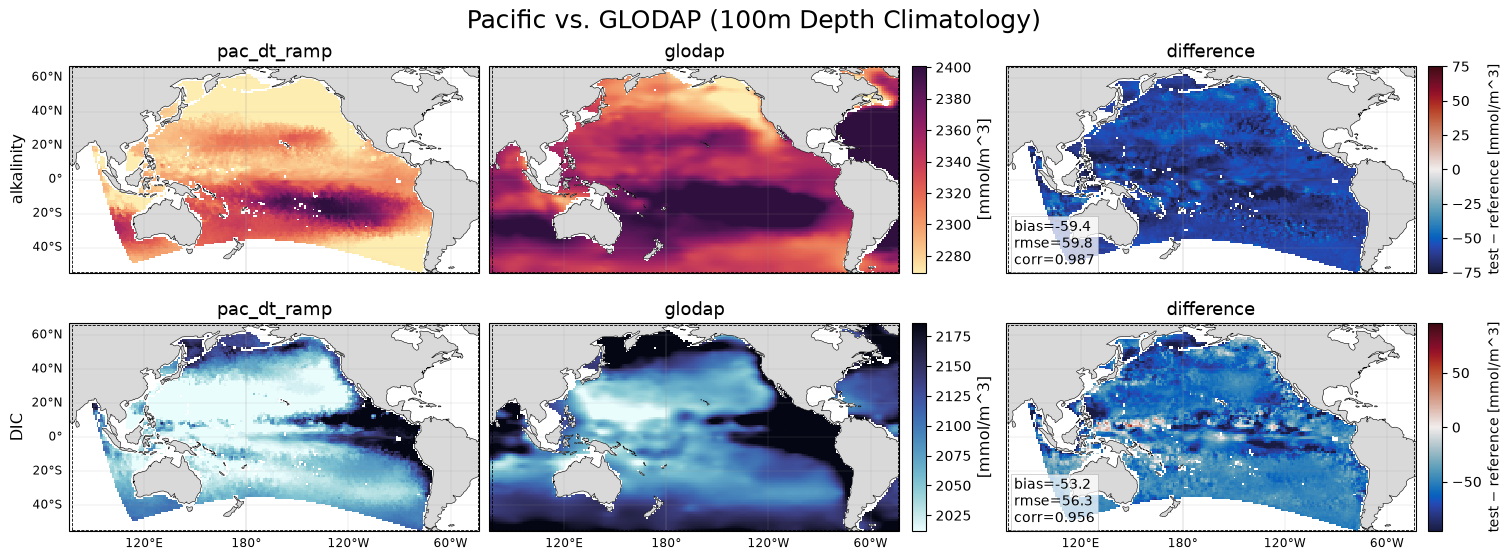

In [26]:
%%time

vars_to_plot = ["alkalinity", "dissolved_inorganic_carbon"]

glodap_100m = osk.compare(
    aggregate={"time": "mean"},
    reference=["glodap"],
    test=cat_name,
    variables=vars_to_plot,
    depths=[100],  # depths is a convenience
)
fig = glodap_100m.plot(figsize=(15,5.5), title="Pacific vs. GLODAP (100m Depth Climatology)")

### Could also compare one variable by depth

/tmp/ipykernel_1478335/2033527028.py:1: UserWarning: 'alkalinity' resolved to standard_name 'sea_water_alkalinity_expressed_as_mole_equivalent' (compare variables=)
  bydepth = osk.compare(


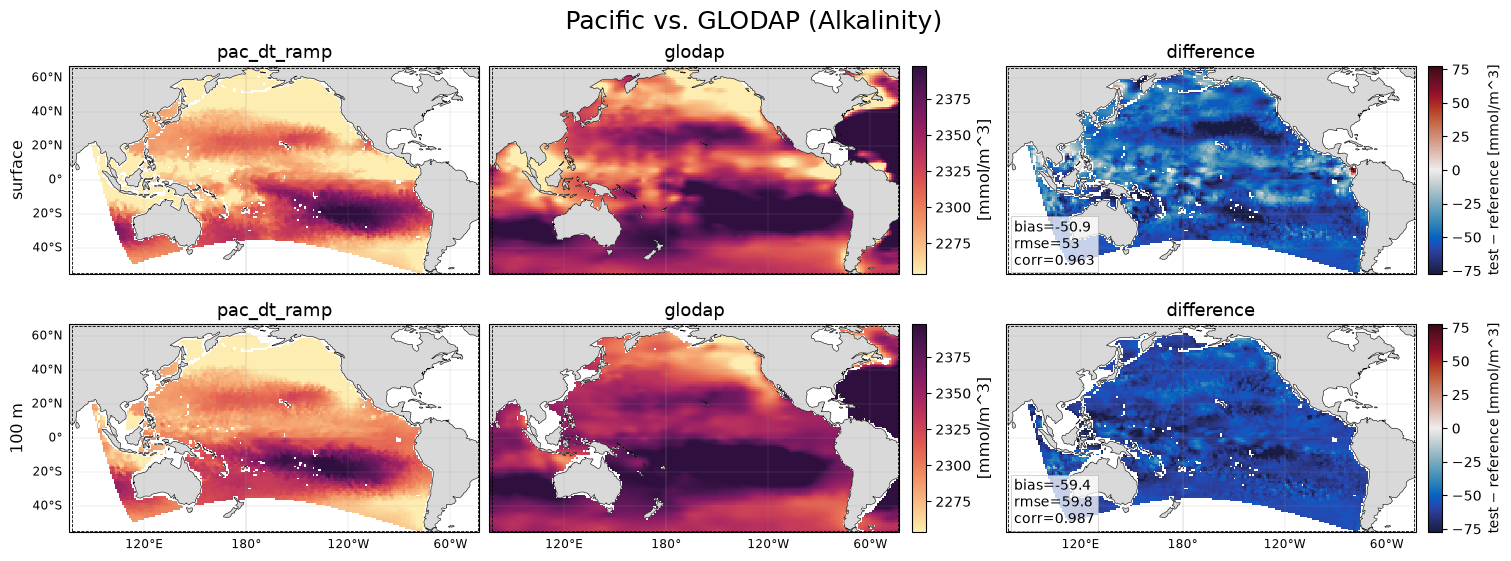

In [10]:
bydepth = osk.compare(
    aggregate={"time": "mean"},
    reference=["glodap"],
    test=cat_name,
    variables=["alkalinity"],
    depths=["surface", 100],
)
fig = bydepth.plot(figsize=(15, 5.5), title="Pacific vs. GLODAP (Alkalinity)", shared_limits=True,)

## Satellite Chlorophyll

In [14]:
osk.find(variable="chlorophyll")

['erdMH1chla1day_R2022NRT',
 'erdMH1chla1day_R2022SQ',
 'erdMWchla1day',
 'noaacwNPPN20S3ASCIDINEOF2kmDaily',
 'productivity_viirs_snpp_daily',
 'productivity_viirs_snpp_nrt_daily',
 'chl_gapfree_my_daily',
 'chl_gapfree_nrt_daily',
 'modis_chl_climatology_apr',
 'modis_chl_climatology_aug',
 'modis_chl_climatology_dec',
 'modis_chl_climatology_feb',
 'modis_chl_climatology_jan',
 'modis_chl_climatology_jul',
 'modis_chl_climatology_jun',
 'modis_chl_climatology_mar',
 'modis_chl_climatology_may',
 'modis_chl_climatology_nov',
 'modis_chl_climatology_oct',
 'modis_chl_climatology_sep',
 'modis_chl_daily_20120101',
 'modis_chl_daily_20120102',
 'ooi-gp02hypm-wfp02-01-flordl000',
 'ooi-gp02hypm-wfp03-01-flordl000',
 'ooi-gp03flma-ris01-05-flortd000',
 'ooi-gp03flmb-ris01-05-flortd000']

In [21]:
osk.describe('modis_chl_climatology_jan')

source: MODIS Aqua Chlorophyll:modis_chl_climatology_jan
  path: /home/x-kthyng/packages/ocean-skill/catalogs/modis_aqua.yaml
  axes: {'X': 'lon', 'Y': 'lat'}
  featureType: grid
  featureType_source: inferred
  geospatial_lat_max: 89.97916412353516
  geospatial_lat_min: -89.97917175292969
  geospatial_lon_max: 179.9791717529297
  geospatial_lon_min: -179.9791717529297
  lon_convention: -180-180
  period: monthly_climatology
  standard_names: {'chlor_a': 'mass_concentration_of_chlorophyll_in_sea_water'}
  variables: ['mass_concentration_of_chlorophyll_in_sea_water']

In [22]:
%%time

CHL = "chlorophyll"
# CHL = "mass_concentration_of_chlorophyll_a_in_sea_water"

chl = osk.compare(
    reference=['modis_chl_climatology_jan'],
    test=cat_name,
    variables=[{"sum": ["spChl", "diatChl", "diazChl"], "standard_name": CHL}],
    select={"T": "2010-01", "Z": {"min": 0, "max": 10}},
    aggregate={"T": "mean", "Z": "mean"},
)

# GET MODIS BACK!!
fig = chl.plot()

syntax error, unexpected WORD_WORD, expecting SCAN_ATTR or SCAN_DATASET or SCAN_ERROR
context: Rate^ Limiting - Too Many Requests


CPU times: user 146 ms, sys: 57 ms, total: 204 ms
Wall time: 361 ms


OSError: [Errno -77] NetCDF: Access failure: 'https://oceandata.sci.gsfc.nasa.gov/opendap/MODISA/L3SMI/2003/0101/AQUA_MODIS.20030101_20220131.L3m.MC.CHL.chlor_a.4km.nc'

## Summary Diagrams

Show all comparisons on one Taylor and one Target diagram.

CPU times: user 619 ms, sys: 338 ms, total: 958 ms
Wall time: 962 ms


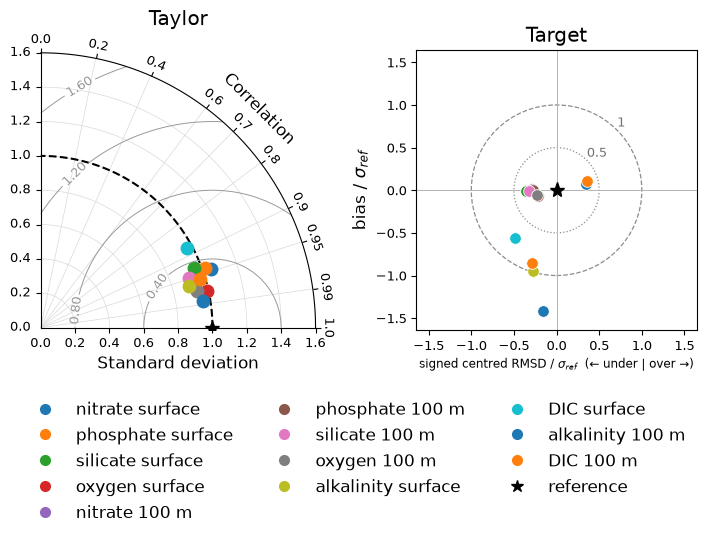

In [28]:
%%time

fig = osk.summary([woa_surface, woa_100m, glodap_surface, glodap_100m])              # Taylor + target, pooled
# osk.summary([woa_surface, woa_100m, glodap_surface, glodap_100m, chl])              # Taylor + target, pooled


## Other things

There are lots of other features I can demo like animation and interactive versions of the plots.